## About This Entry

As our needs become more complex, relying on data explicitly present in a table becomes less of an option. Suppose, for example, that I only want to grab data from the three warehouses with the most items sent to clients in the last three months. If the available table follows the OLTP approach and therefore records each transaction, but does not aggregate the data, I will first have to find out which were the three most active warehouses in order to then filter the table using this information. This can be done with subqueries: queries implemented inside of a parent query — mainly inside the `SELECT`, `FROM`, and `WHERE` clauses — in order to allow for more complex data retrievals.

Even though they are highly useful, subqueries may cause two kinds of problems. First, depending on their complexity and frequency of usage, they can make the code long and hard to read, harming its maintenance. Second, since they can create loops in which they are rerun for each row in a table, subqueries can become incredibly taxing if used carelessly, especially when dealing with large datasets.

To solve these problems, we have two available options. The first one is useful when the subquery is being used inside the `WHERE` clause to filter a table based on values from another. In this case, we can simply `JOIN` the tables and then apply the filter — SQL will then leverage its indexing feature to produce a faster query. The strategy is useful but somewhat limited, since it only solves the problem of subqueries that are inside `WHERE` and that do not perform calculations — also, it does not really improve readability much.
The second option is much more elegant and versatile: Common Table Expressions (CTEs). CTEs save the results of a query in tabular form and allow us to retrieve them by using an alias. If we run `WITH <alias> AS (<query>)`, we can then use this alias in any part of the query to access those results. The advantage, of course, is that the computations need not be performed over and over again, since their results have been stored in a temporary table. Also, aliases are much easier to read than the queries they stand for.

In terms of clarity, CTEs far surpass both joins and subqueries, greatly improving code readability. In terms of performance, though, the matter is much more complex, and we do not have a one-size-fits-all solution. For queries that are expected to deal with large tables, the best option is to have SQL `EXPLAIN` its execution plan and look for any possible bottlenecks.

As you can see, the SQL feature I presented here is a double-edged sword: even though they allow operations that would not be possible without them, subqueries can be awfully harmful for a query's performance. Either way, any data analyst working with SQL must know how to leverage them.

## Analysis Context

Again, I am uploading code I have written to solve [Datacamp](https://www.datacamp.com/)'s challenges. This entry, in particular, is composed of code from two different challenges. The first one illustrates how we can use subqueries to get data on the oldest running business in each continent. The dataset is composed of two tables with the following structure:

`businesses`
|Column|Description|
|------|-----------|
|`business`|Name of the business (varchar)|
|`year_founded`|Year the business was founded (int)|
|`category_code`|Code for the business category (varchar)|
|`country_code`|ISO 3166-1 three-letter country code (char)|

`countries`
|Column|Description|
|------|-----------|
|`country_code`|ISO 3166-1 three-letter country code (varchar)|
|`country`|Name of the country (varchar)|
|`continent`|Name of the continent the country exists in (varchar)|

Below, you can see the first 10 lines of each table, the code and its output.

![businesses table.png](<attachment:businesses table.png>)
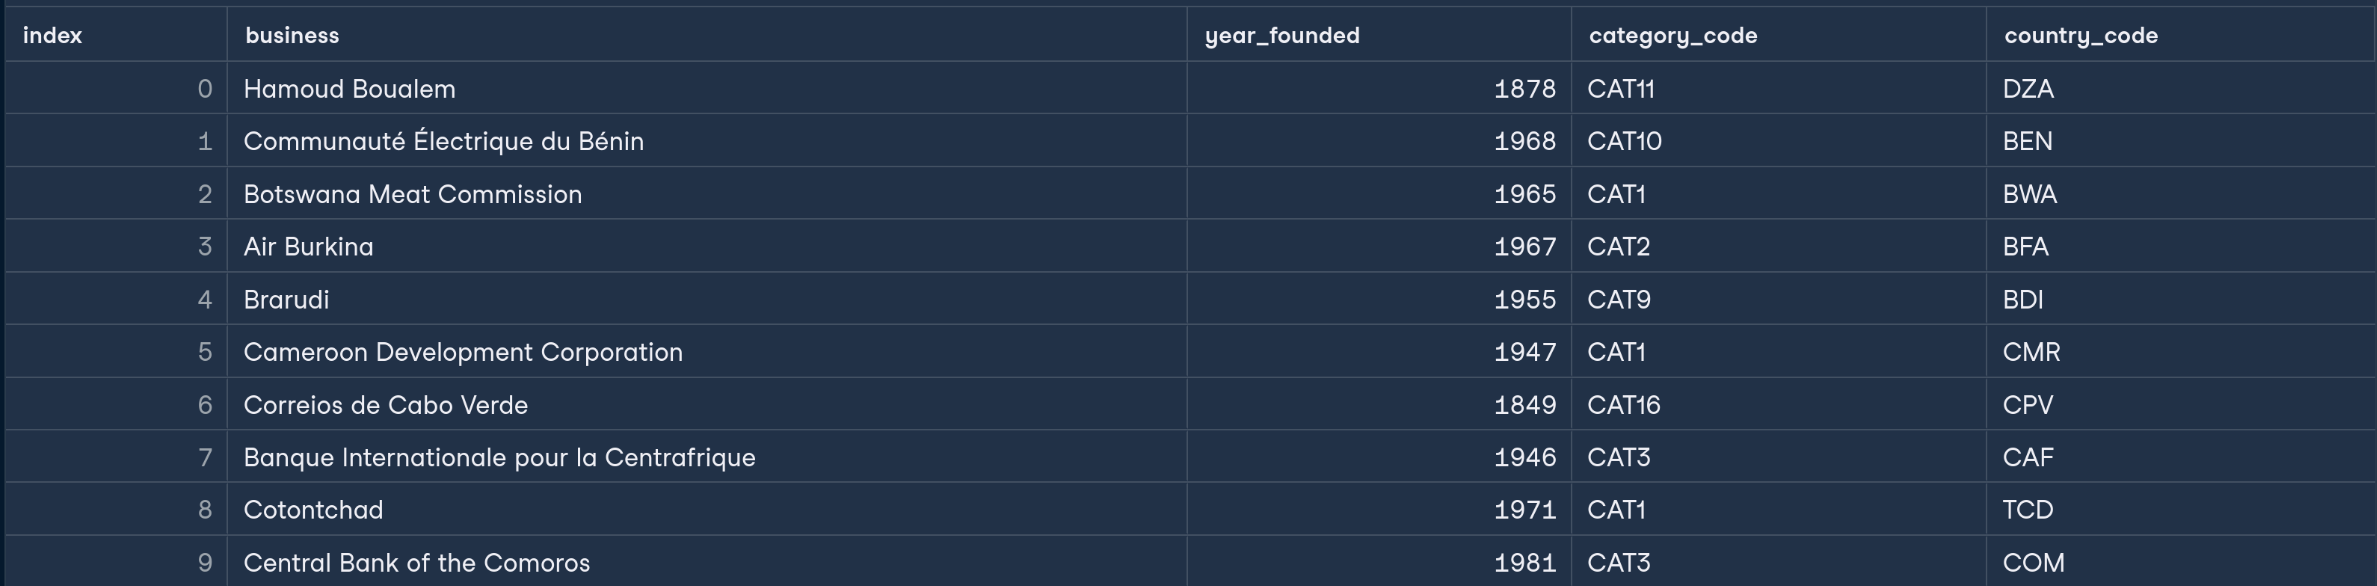

![countries table-2.png](<attachment:countries table-2.png>)
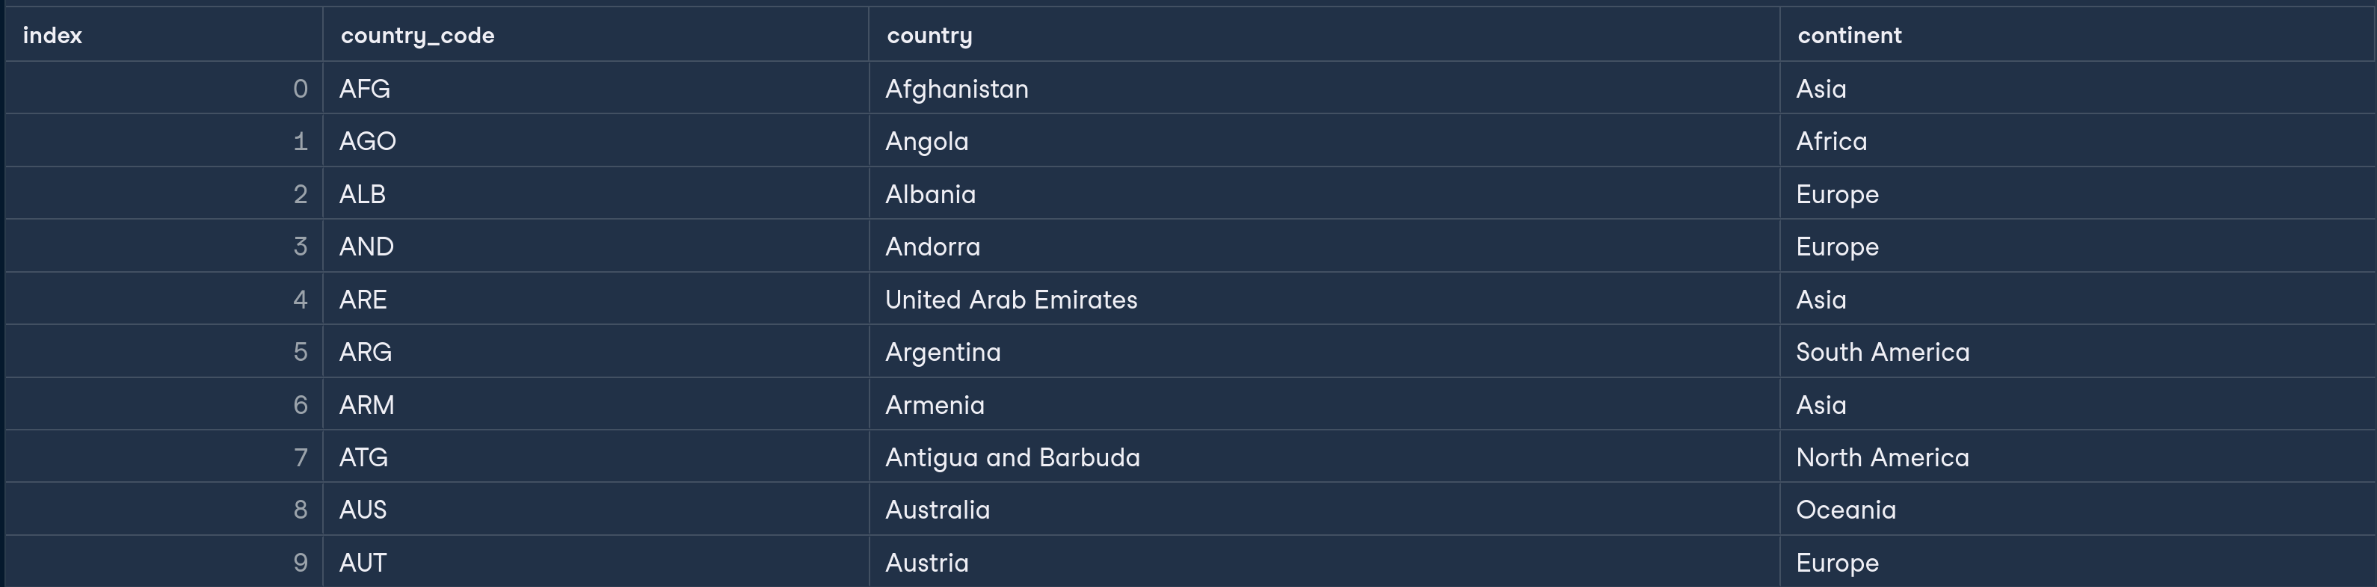

In [ ]:
SELECT c.continent, c.country, b.business, b.year_founded
  FROM businesses AS b
	   INNER JOIN countries AS c USING(country_code)
 WHERE year_founded IN (SELECT MIN(year_founded)
						  FROM businesses AS b
						 INNER JOIN countries AS c USING(country_code)
						 GROUP BY continent);

![oldest business by continent.png](<attachment:oldest business by continent.png>)
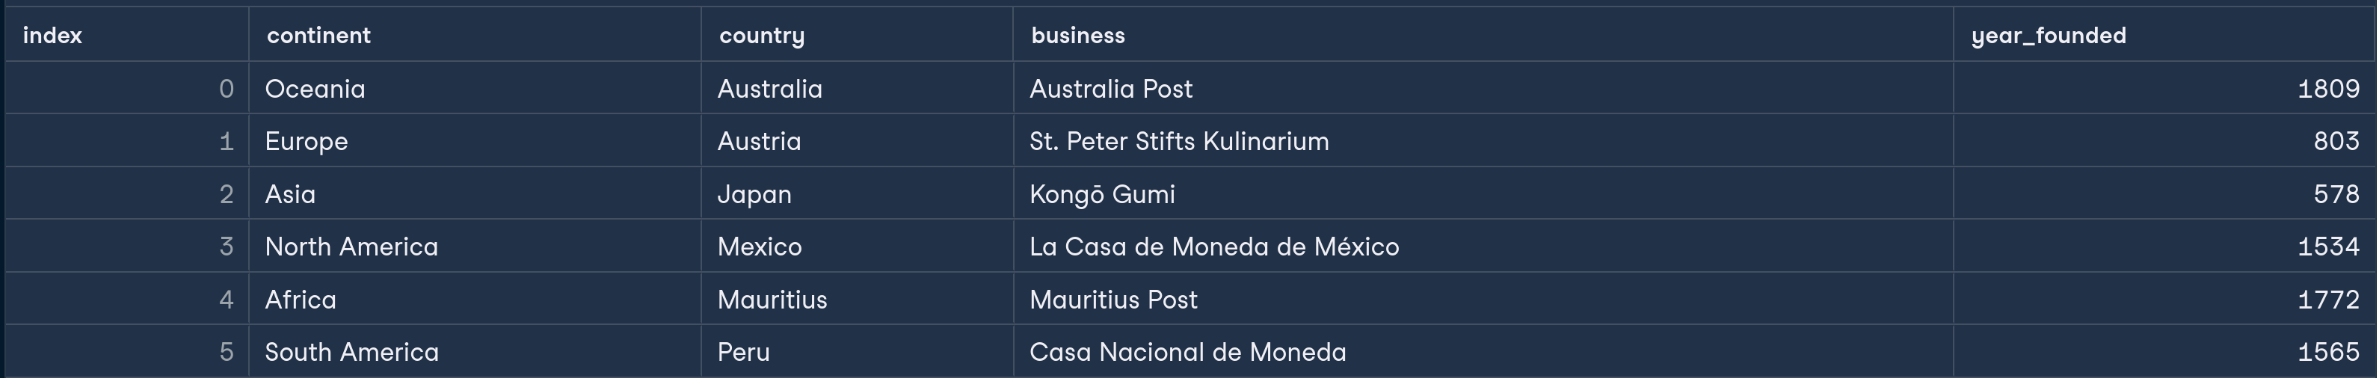

As you can see, the subquery inside the `WHERE` clause was important for selecting the earliest year that appears in the dataset for each continent, therefore allowing us to filter the data based on such information. As I said, though, subqueries can become unreasonably complex and harm not only the code's readability, but also its performance.

The example below illustrates how Common Table Expressions are a much more ellegant approach. The code first registers the top 3 industries in number of unicorn¹ companies across the years in a CTE and then use this information to calculate how many companies became unicorns in each year for each of the top 3 industries, as well as the average valuation of those companies in billions of US dolars.

¹ Privately held startup companies with a current valuation of US$1 billion or more.

The tables used have the following structure:

### dates
| Column       | Description                                  |
|------------- |--------------------------------------------- |
| `company_id`   | A unique ID for the company.                 |
| `date_joined` | The date that the company became a unicorn.  |
| `year_founded` | The year that the company was founded.       |

### funding
| Column           | Description                                  |
|----------------- |--------------------------------------------- |
| `company_id`       | A unique ID for the company.                 |
| `valuation`        | Company value in US dollars.                 |
| `funding`          | The amount of funding raised in US dollars.  |
| `select_investors` | A list of key investors in the company.      |

### industries
| Column       | Description                                  |
|------------- |--------------------------------------------- |
| `company_id`   | A unique ID for the company.                 |
| `industry`     | The industry that the company operates in.   |

You can see snapshots of each of them below.

![unicorn dates table.png](<attachment:unicorn dates table.png>)
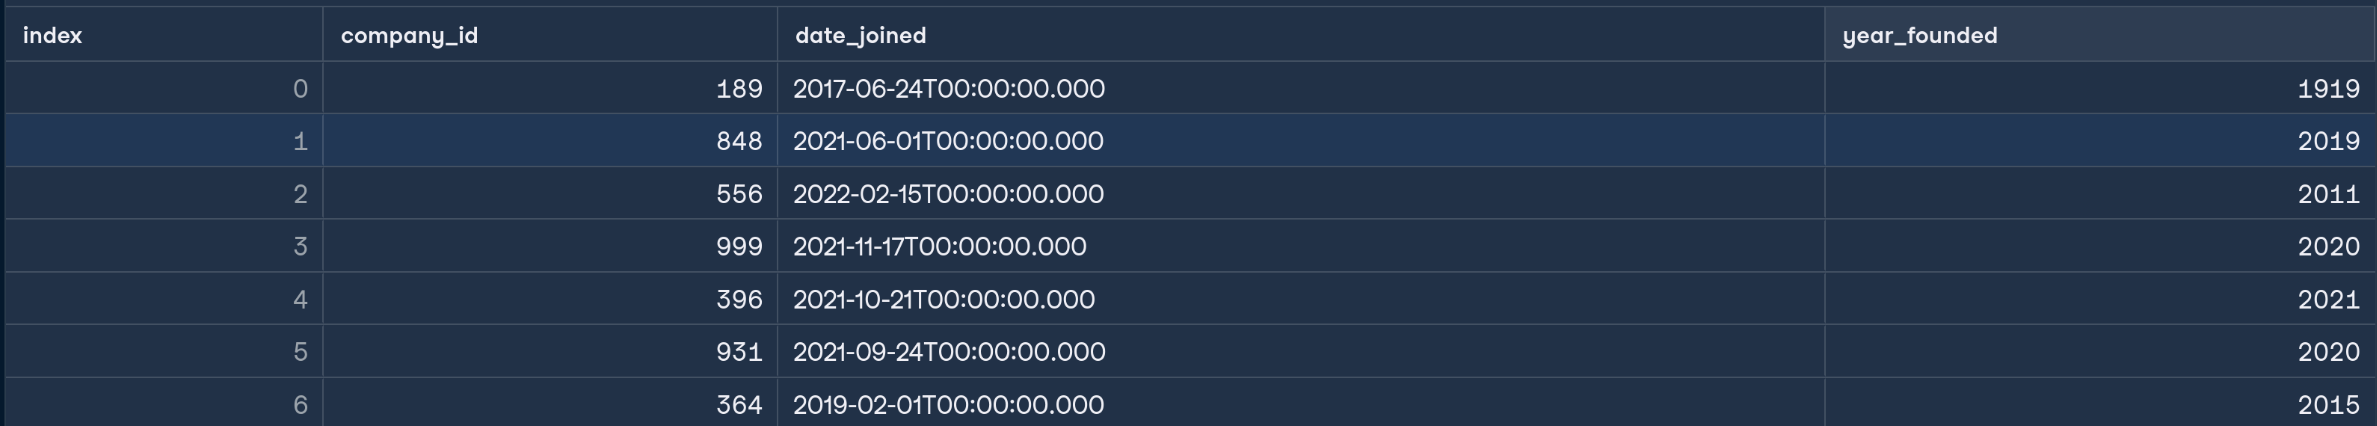

![unicorn funding table.png](<attachment:unicorn funding table.png>)
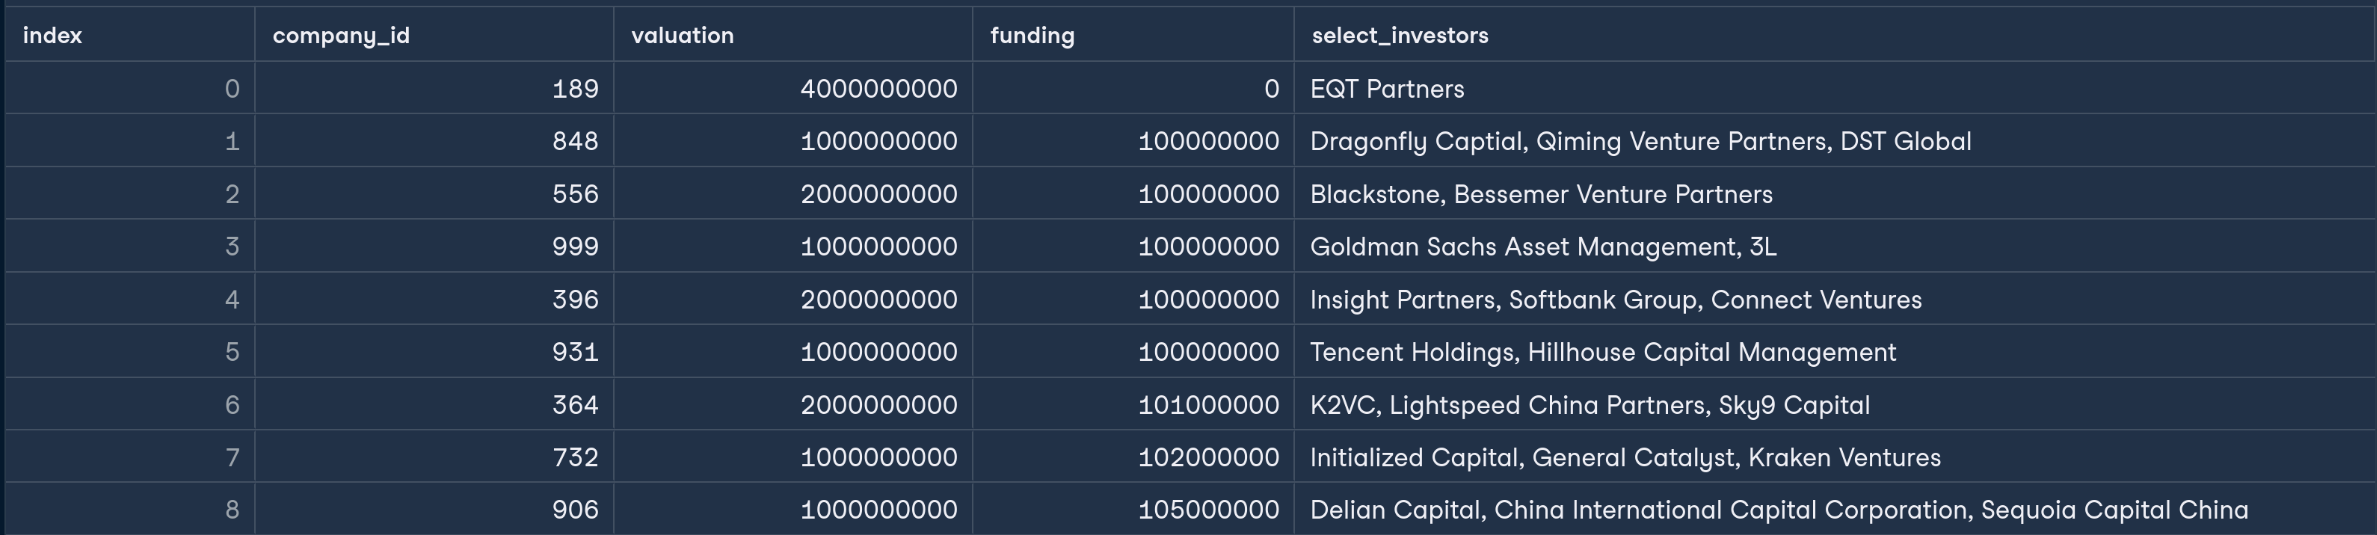

![unicorn industries table-2.png](<attachment:unicorn industries table-2.png>)
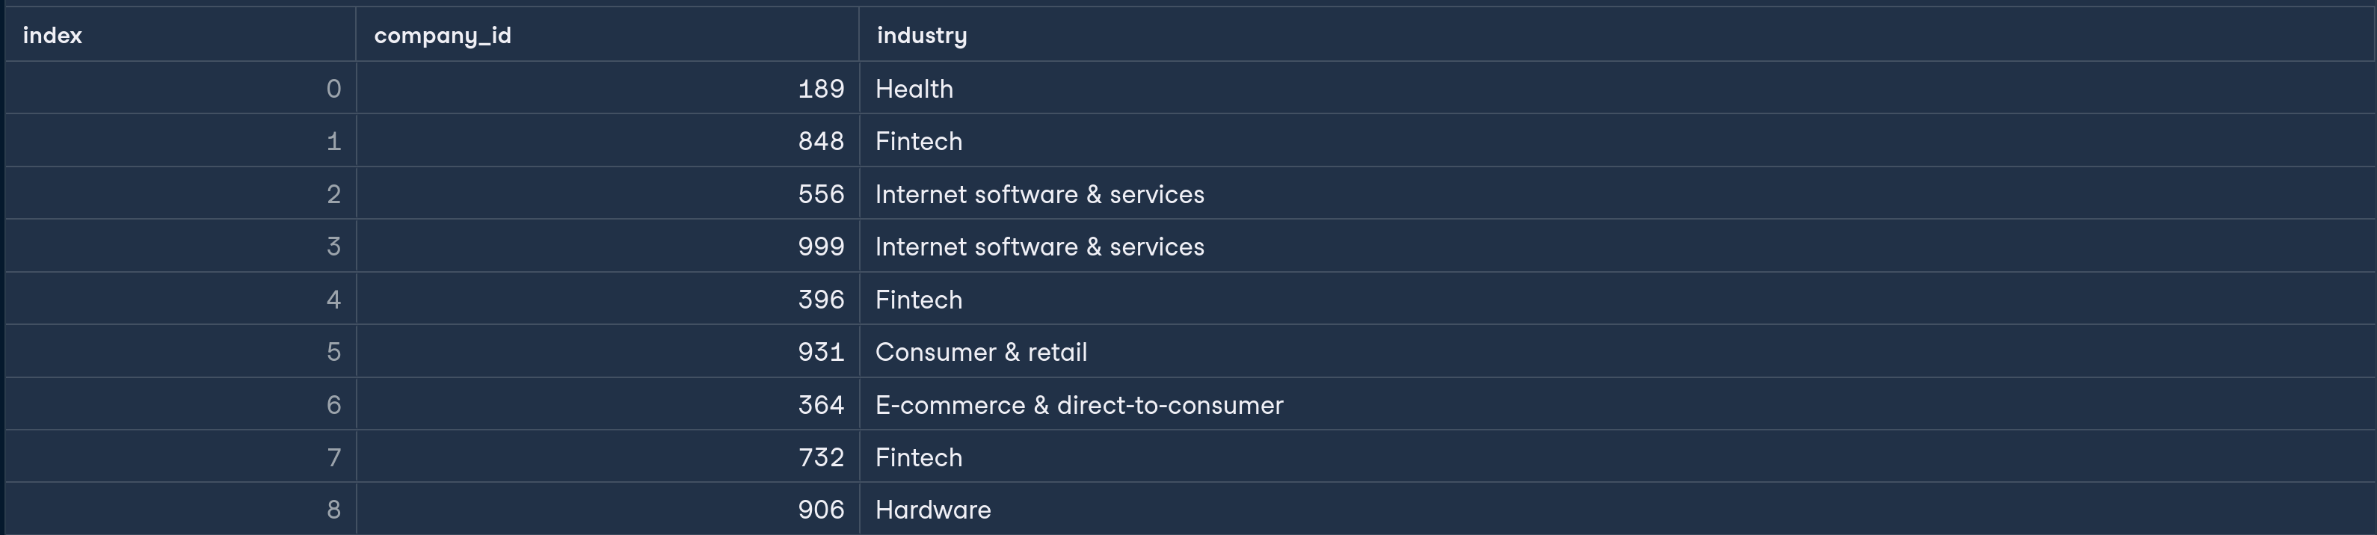

In [ ]:
WITH top3_industries AS (
SELECT industry, COUNT(DISTINCT(company_id)) AS num_unicorns
  FROM dates
	   INNER JOIN industries
	   USING (company_id)
 WHERE EXTRACT(YEAR FROM date_joined) BETWEEN 2019 AND 2021
 GROUP BY industry
 ORDER BY num_unicorns DESC
 LIMIT 3)

SELECT industry,
	   EXTRACT(YEAR FROM date_joined) AS year,
	   COUNT(DISTINCT(company_id)) AS num_unicorns,
	   ROUND(AVG(valuation)/1000000000, 2) AS average_valuation_billions
  FROM dates
	   INNER JOIN industries
	   USING (company_id)
	   INNER JOIN funding
	   USING (company_id)
 WHERE EXTRACT(YEAR FROM date_joined) BETWEEN 2019 AND 2021
	   AND industry IN (SELECT industry FROM top3_industries)
 GROUP BY industry, year
 ORDER BY year DESC, num_unicorns DESC;

If it wasn't for the ability to create CTEs, the whole subquery would need to be placed inside the `WHERE` filter and the code would look like this:

In [ ]:
SELECT industry,
	   EXTRACT(YEAR FROM date_joined) AS year,
	   COUNT(DISTINCT(company_id)) AS num_unicorns,
	   ROUND(AVG(valuation)/1000000000, 2) AS average_valuation_billions
  FROM dates
	   INNER JOIN industries
	   USING (company_id)
	   INNER JOIN funding
	   USING (company_id)
 WHERE EXTRACT(YEAR FROM date_joined) BETWEEN 2019 AND 2021
	   AND industry IN (SELECT industry FROM (SELECT industry, COUNT(DISTINCT(company_id)) AS num_unicorns
  												FROM dates
	   												 INNER JOIN industries
	   												 USING (company_id)
 											   WHERE EXTRACT(YEAR FROM date_joined) BETWEEN 2019 AND 2021
 											   GROUP BY industry
 											   ORDER BY num_unicorns DESC
 											   LIMIT 3))
 GROUP BY industry, year
 ORDER BY year DESC, num_unicorns DESC;

In this case, not only is the readability severely impacted, but the use of the subquery instead of the CTE may cause it to be rerun multiple times, depending on how the query optimizer plans the query execution, which would surely have a huge impact on its performance. And we're only talking about one subquery! You can imagine how messy the code would become if we needed to use multiple subqueries without having the ability to turn them into CTEs.